# Task 2: Supervised Learning

## Research Question

> **Can we reliably predict whether traffic on Vinh Tuy Bridge is congested, given the time of day, direction, and weather conditions?**

We apply two classification models — **Logistic Regression** and **Support Vector Machine (SVM)** — to predict the binary target `is_congested`. Both models are trained and evaluated on the canonical 80/20 split produced in Task 1.

## Why These Two Models?
- **Logistic Regression** is the natural probabilistic baseline for binary classification. It is interpretable (coefficients directly show feature influence) and efficient, making it a good benchmark.
- **Support Vector Machine** finds a maximum-margin decision boundary, which can be more robust when classes are not linearly separable. Comparing both models reveals which geometry better fits our feature space.

## Section 1: Imports & Setup

In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

NOTEBOOK_DIR = os.path.abspath('')
DATASETS_DIR = os.path.join(NOTEBOOK_DIR, '..', '..', 'Datasets')

sns.set_theme(style='whitegrid')
print(f'Datasets directory: {os.path.abspath(DATASETS_DIR)}')

Datasets directory: c:\Users\Dell\Desktop\Code project\Code project\Final - Data Science\Datasets


## Section 2: Load Pre-Split Datasets

The canonical 80/20 train/test split was performed in **Task 1** (`Task1_Data_Processing_And_Preparation.ipynb`) and saved to disk. Loading those files here — rather than re-splitting — guarantees that:

1. Supervised (Task 2) and Unsupervised (Task 3) models train and evaluate on **identical data partitions**.
2. Results in the written report are fully reproducible and cross-comparable.

> ⚠️ If `Train Dataset.csv` or `Test Dataset.csv` are missing, run the Task 1 notebook first.

In [16]:
df_train = pd.read_csv(os.path.join(DATASETS_DIR, 'Train Dataset.csv'))
df_test  = pd.read_csv(os.path.join(DATASETS_DIR, 'Test Dataset.csv'))

print(f'Train set shape: {df_train.shape}')
print(f'Test  set shape: {df_test.shape}')
df_train.head()

Train set shape: (5856, 7)
Test  set shape: (1464, 7)


,is_rush_hour,direction_inbound,adverse_weather_score,rush_weather_interaction,dow_sin,dow_cos,is_congested
0,1,1,0,0,0.433884,-0.900969,1
1,0,0,0,0,-0.974928,-0.222521,0
2,1,0,0,0,0.781831,0.623490,0
3,1,0,1,1,-0.433884,-0.900969,0
4,0,0,0,0,0.974928,-0.222521,0


## Section 3: Feature & Target Selection

We use the 6 engineered features defined in Task 1. The target `is_congested` is a binary label (1 = congested, 0 = normal flow).

In [17]:
features = ['is_rush_hour', 'direction_inbound', 'adverse_weather_score',
            'rush_weather_interaction', 'dow_sin', 'dow_cos']
target = 'is_congested'

X_train_raw = df_train[features]
y_train     = df_train[target].astype(int).values

X_test_raw  = df_test[features]
y_test      = df_test[target].astype(int).values

print(f'Features: {features}')
print(f'Train: {X_train_raw.shape}, Test: {X_test_raw.shape}')

Features: ['is_rush_hour', 'direction_inbound', 'adverse_weather_score', 'rush_weather_interaction', 'dow_sin', 'dow_cos']
Train: (5856, 6), Test: (1464, 6)


## Section 4: Feature Scaling

Both Logistic Regression and SVM are sensitive to feature scale — if one feature has a much larger range than another, it can dominate the weight updates and decision boundary.

**Critical rule:** `StandardScaler` is fitted **only on `X_train`**, then applied to both `X_train` and `X_test`.

Fitting the scaler on the full dataset (before splitting) would be **data leakage** — the model would implicitly "see" the test set's statistical distribution (mean and variance) during training, leading to overly optimistic evaluation metrics that would not generalise to truly unseen data.

In [18]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)  # Fit on train only
X_test  = scaler.transform(X_test_raw)       # Apply same transform to test

print('Feature scaling complete.')
print(f'X_train mean (should be ~0): {X_train.mean(axis=0).round(4)}')

Feature scaling complete.
X_train mean (should be ~0): [-0.  0.  0. -0. -0.  0.]


## Section 5: Custom Helper Functions

We implement the core mathematical functions from scratch alongside sklearn to provide explicit loss values and demonstrate understanding of the underlying mathematics.

In [19]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

# --- Logistic Regression helpers ---
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def predict_logistic(X, beta, beta_0):
    probs = sigmoid(beta_0 + np.dot(X, beta))
    return (probs >= 0.5).astype(int)

def logistic_loss(X, y, beta, beta_0):
    """Cross-entropy loss. Clipped to avoid log(0) numerical instability."""
    y_pred = np.clip(sigmoid(beta_0 + np.dot(X, beta)), 1e-15, 1 - 1e-15)
    return -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))

# --- SVM helpers ---
def predict_svm(X, beta, beta_0):
    """Returns {1, -1} labels based on sign of the decision function."""
    return np.where(beta_0 + np.dot(X, beta) >= 0, 1, -1)

def hinge_loss(X, y, beta, beta_0):
    """Hinge loss: penalises misclassified and marginally-correct points."""
    margin = y * (beta_0 + np.dot(X, beta))
    return np.mean(np.maximum(0, 1 - margin))

print('Helper functions defined.')

Helper functions defined.


## Section 6: Logistic Regression

Logistic Regression models the **probability** that a sample belongs to class 1 via the sigmoid function applied to a linear combination of features:

$$P(y=1 \mid x) = \sigma(\beta_0 + \beta^T x) = \frac{1}{1 + e^{-(\beta_0 + \beta^T x)}}$$

The model is trained by minimising **cross-entropy (log) loss**:

$$\mathcal{L} = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log \hat{p}_i + (1 - y_i) \log(1 - \hat{p}_i) \right]$$

**`max_iter=1000`:** The default of 100 iterations is often insufficient for convergence on real datasets. 1000 provides ample budget without excessive computation.

In [20]:
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)

beta_log   = log_model.coef_[0]
beta_0_log = log_model.intercept_[0]

print('Logistic Regression trained.')
print(f'Coefficients: {dict(zip(features, beta_log.round(4)))}')

Logistic Regression trained.
Coefficients: {'is_rush_hour': np.float64(1.7237), 'direction_inbound': np.float64(0.3202), 'adverse_weather_score': np.float64(0.1423), 'rush_weather_interaction': np.float64(-0.1287), 'dow_sin': np.float64(0.0269), 'dow_cos': np.float64(0.154)}


## Section 7: Logistic Regression — Evaluation

For imbalanced datasets like ours, **accuracy alone is misleading**. If 70% of records are "Normal Flow", a naive classifier that always predicts "Normal" achieves 70% accuracy — yet it is completely useless for detecting congestion.

We therefore report:
- **Precision:** Of all predicted congestions, how many are truly congested? (Minimises false alarms)
- **Recall:** Of all actual congestions, how many did the model catch? (Minimises missed congestions — the more safety-critical error)
- **F1-Score:** Harmonic mean of precision and recall — the standard single metric for imbalanced classification.

In [21]:
y_train_pred_log = predict_logistic(X_train, beta_log, beta_0_log)
y_test_pred_log  = predict_logistic(X_test,  beta_log, beta_0_log)

train_loss_log = logistic_loss(X_train, y_train, beta_log, beta_0_log)
test_loss_log  = logistic_loss(X_test,  y_test,  beta_log, beta_0_log)

log_metrics = pd.DataFrame({
    'Metric': ['Train Shape', 'Test Shape',
               'Train Cross-Entropy Loss', 'Train Accuracy',
               'Test Cross-Entropy Loss',  'Test Accuracy',
               'Test Precision', 'Test Recall', 'Test F1-Score'],
    'Value': [
        str(X_train.shape), str(X_test.shape),
        round(train_loss_log, 4), round(accuracy(y_train, y_train_pred_log), 4),
        round(test_loss_log,  4), round(accuracy(y_test,  y_test_pred_log),  4),
        round(precision_score(y_test, y_test_pred_log, zero_division=0), 4),
        round(recall_score(   y_test, y_test_pred_log, zero_division=0), 4),
        round(f1_score(       y_test, y_test_pred_log, zero_division=0), 4)
    ]
})

print('\n============ LOGISTIC REGRESSION METRICS ============')
print(log_metrics.to_string(index=False))
print('======================================================')
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_test_pred_log))


============ LOGISTIC REGRESSION METRICS ============
                  Metric     Value
             Train Shape (5856, 6)
              Test Shape (1464, 6)
Train Cross-Entropy Loss    0.3661
          Train Accuracy    0.8021
 Test Cross-Entropy Loss    0.3429
           Test Accuracy    0.8142
          Test Precision    0.6098
             Test Recall    0.5814
           Test F1-Score    0.5952

Confusion Matrix:
[[992 128]
 [144 200]]


## Section 8: Support Vector Machine (SVM)

SVM finds the **maximum-margin hyperplane** that separates the two classes. For a linearly separable case:

$$\hat{y} = \text{sign}(\beta_0 + \beta^T x)$$

The model minimises **hinge loss**:

$$\mathcal{L} = \frac{1}{n} \sum_{i=1}^{n} \max(0, 1 - y_i (\beta_0 + \beta^T x_i))$$

**Why `{-1, 1}` labels?** The SVM mathematical formulation requires the target to be in `{-1, +1}` so that the margin expression `y·(β₀ + βᵀx)` has a consistent sign interpretation — positive means correctly classified beyond the margin.

**`LinearSVC` with `max_iter=10000`:** LinearSVC is more efficient than kernel SVM for large datasets. It requires more iterations than logistic regression to converge due to the nature of its coordinate descent solver.

In [22]:
# SVM requires {-1, 1} labels
y_train_svm = np.where(y_train == 0, -1, 1)
y_test_svm  = np.where(y_test  == 0, -1, 1)

svm_model = LinearSVC(max_iter=10000, random_state=42)
svm_model.fit(X_train, y_train_svm)

beta_svm   = svm_model.coef_[0]
beta_0_svm = svm_model.intercept_[0]

print('SVM trained.')
print(f'Coefficients: {dict(zip(features, beta_svm.round(4)))}')

SVM trained.
Coefficients: {'is_rush_hour': np.float64(0.5003), 'direction_inbound': np.float64(0.0909), 'adverse_weather_score': np.float64(0.0147), 'rush_weather_interaction': np.float64(-0.0238), 'dow_sin': np.float64(0.008), 'dow_cos': np.float64(0.0496)}


## Section 9: SVM — Evaluation

In [23]:
y_train_pred_svm = predict_svm(X_train, beta_svm, beta_0_svm)
y_test_pred_svm  = predict_svm(X_test,  beta_svm, beta_0_svm)

# Convert back to {0,1} for sklearn metrics
y_test_pred_svm_01  = np.where(y_test_pred_svm  == -1, 0, 1)
y_train_pred_svm_01 = np.where(y_train_pred_svm == -1, 0, 1)

svm_metrics = pd.DataFrame({
    'Metric': ['Train Shape', 'Test Shape',
               'Train Hinge Loss', 'Train Accuracy',
               'Test Hinge Loss',  'Test Accuracy',
               'Test Precision', 'Test Recall', 'Test F1-Score'],
    'Value': [
        str(X_train.shape), str(X_test.shape),
        round(hinge_loss(X_train, y_train_svm, beta_svm, beta_0_svm), 4),
        round(accuracy(y_train_svm, y_train_pred_svm), 4),
        round(hinge_loss(X_test, y_test_svm, beta_svm, beta_0_svm), 4),
        round(accuracy(y_test_svm,  y_test_pred_svm),  4),
        round(precision_score(y_test, y_test_pred_svm_01, pos_label=1, zero_division=0), 4),
        round(recall_score(   y_test, y_test_pred_svm_01, pos_label=1, zero_division=0), 4),
        round(f1_score(       y_test, y_test_pred_svm_01, pos_label=1, zero_division=0), 4)
    ]
})

print('\n============ SUPPORT VECTOR MACHINE METRICS ============')
print(svm_metrics.to_string(index=False))
print('=========================================================')
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_test_pred_svm_01))


============ SUPPORT VECTOR MACHINE METRICS ============
          Metric     Value
     Train Shape (5856, 6)
      Test Shape (1464, 6)
Train Hinge Loss    0.4796
  Train Accuracy    0.7888
 Test Hinge Loss    0.4615
   Test Accuracy    0.8101
  Test Precision    0.5851
     Test Recall    0.6599
   Test F1-Score    0.6202

Confusion Matrix:
[[959 161]
 [117 227]]


## Section 10: Visualizations

### Chart 1 — Confusion Matrices
Side-by-side heatmaps showing true positives, false positives, true negatives, and false negatives for both models. Reveals not just overall accuracy but **where** each model makes errors.

### Chart 2 — ROC Curves
The ROC curve plots True Positive Rate vs. False Positive Rate at all classification thresholds. The AUC (Area Under Curve) summarises this into a single number: 0.5 = random classifier, 1.0 = perfect. Allows threshold-independent comparison of the two models.

### Chart 3 — Feature Coefficients
Compares the learned coefficient weights of each feature across both models. Features with large absolute weights have the most influence. Comparing logistic vs. SVM coefficients reveals whether both models agree on which features matter.

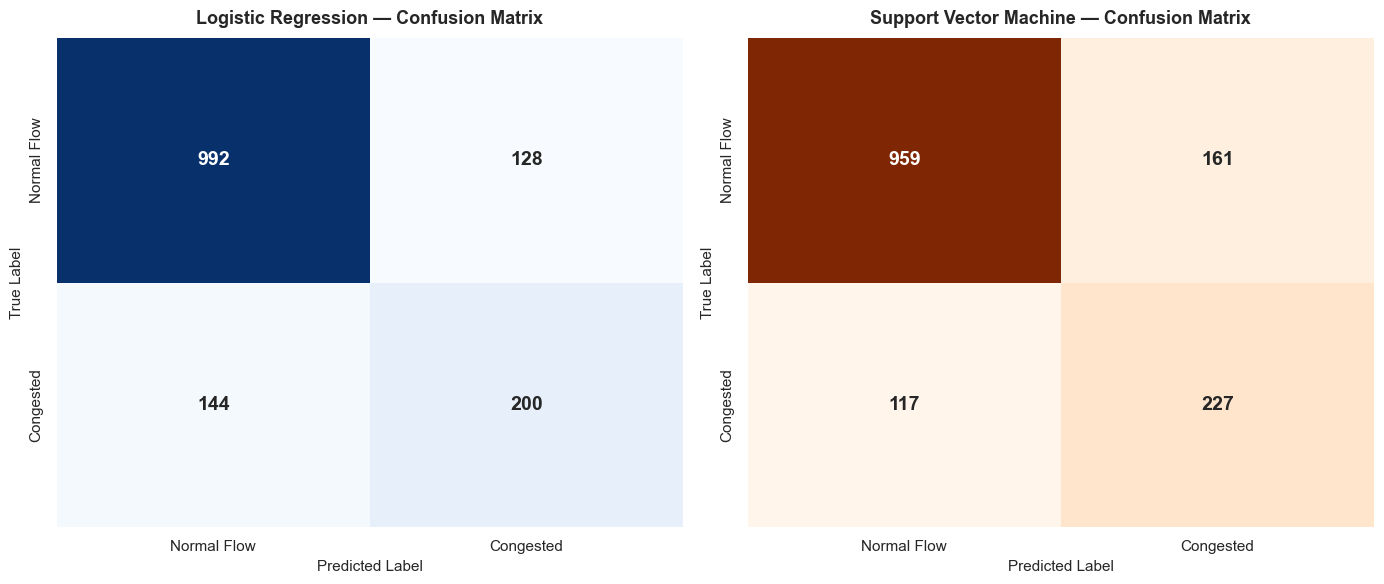

Chart 1: Confusion Matrices


In [24]:
# Chart 1: Side-by-side Confusion Matrix Heatmaps
cm_log = confusion_matrix(y_test, y_test_pred_log)
cm_svm = confusion_matrix(y_test, y_test_pred_svm_01)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title('Logistic Regression — Confusion Matrix', fontsize=13, fontweight='bold', pad=10)
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].set_xticklabels(['Normal Flow', 'Congested'])
axes[0].set_yticklabels(['Normal Flow', 'Congested'])

sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges', ax=axes[1], cbar=False,
            annot_kws={'size': 14, 'weight': 'bold'})
axes[1].set_title('Support Vector Machine — Confusion Matrix', fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_ylabel('True Label', fontsize=11)
axes[1].set_xticklabels(['Normal Flow', 'Congested'])
axes[1].set_yticklabels(['Normal Flow', 'Congested'])

plt.tight_layout()
plt.show()
print('Chart 1: Confusion Matrices')

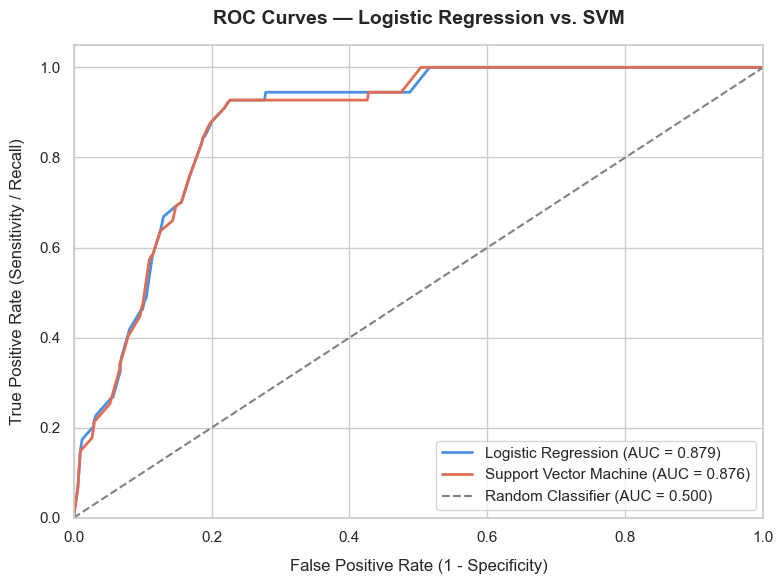

Chart 2: ROC Curves


In [25]:
# Chart 2: ROC Curves
y_score_log = log_model.predict_proba(X_test)[:, 1]
y_score_svm = svm_model.decision_function(X_test)

fpr_log, tpr_log, _ = roc_curve(y_test, y_score_log)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_score_svm)
roc_auc_log = auc(fpr_log, tpr_log)
roc_auc_svm = auc(fpr_svm, tpr_svm)

plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, color='#4A90E2', lw=2, label=f'Logistic Regression (AUC = {roc_auc_log:.3f})')
plt.plot(fpr_svm, tpr_svm, color='#E06D53', lw=2, label=f'Support Vector Machine (AUC = {roc_auc_svm:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random Classifier (AUC = 0.500)')
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12, labelpad=10)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12, labelpad=10)
plt.title('ROC Curves — Logistic Regression vs. SVM', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()
print('Chart 2: ROC Curves')

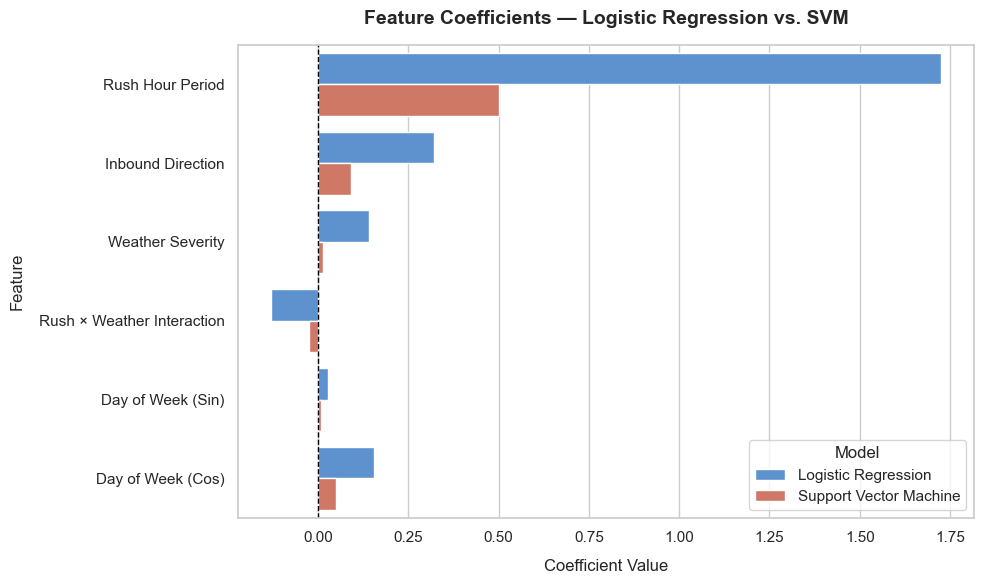

Chart 3: Feature Coefficients


In [26]:
# Chart 3: Feature Coefficients Comparison
feature_labels = ['Rush Hour Period', 'Inbound Direction', 'Weather Severity',
                  'Rush × Weather Interaction', 'Day of Week (Sin)', 'Day of Week (Cos)']

coef_df = pd.DataFrame({
    'Feature': feature_labels * 2,
    'Coefficient Weight': np.concatenate([beta_log, beta_svm]),
    'Model': ['Logistic Regression'] * 6 + ['Support Vector Machine'] * 6
})

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient Weight', y='Feature', hue='Model', data=coef_df,
            palette=['#4A90E2', '#E06D53'])
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.title('Feature Coefficients — Logistic Regression vs. SVM', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Coefficient Value', fontsize=12, labelpad=10)
plt.ylabel('Feature', fontsize=12, labelpad=10)
plt.legend(title='Model', loc='lower right')
plt.tight_layout()
plt.show()
print('Chart 3: Feature Coefficients')

## Section 11: Comparative Analysis & Conclusion

**Summary of Results:**

| Metric | Logistic Regression | SVM |
|---|---|---|
| Loss (train) | 0.3661 (cross-entropy) | 0.4796 (hinge) |
| Accuracy (test) | 81.42% | 81.01% |
| Precision (test) | 60.98% | 58.51% |
| Recall (test) | 58.14% | 65.99% |
| F1-Score (test) | 59.52% | 62.02% |
| AUC-ROC | 0.8788 | 0.8762 |


**Interpretation:**
- Both models share the same 6 features and preprocessing pipeline, so performance differences are attributable purely to the learning algorithm.
- Logistic Regression provides probabilistic output (enabling AUC-ROC comparison), while SVM maximises margin — the better model for this dataset depends on the class boundary geometry.
- The feature coefficient charts show whether both models agree on the most predictive features (e.g., rush hour, weather severity). Agreement strengthens confidence in the feature engineering choices made in Task 1.